# Analysing Air Pollution and Haze Patterns in India Using Data Mining ⛏️

## Required Libraries and Dependencies

pip install pandas numpy matplotlib seaborn scikit-learn

In [1]:
import pandas as pd

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import numpy as np

import calendar
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import seaborn as sns

# Data Preprocessing and Cleaning

In [2]:
# Load dataset
df = pd.read_csv("./../data/city_day.csv")

# Preview columns and data types
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 29531 entries, 0 to 29530
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   City        29531 non-null  str    
 1   Date        29531 non-null  str    
 2   PM2.5       24933 non-null  float64
 3   PM10        18391 non-null  float64
 4   NO          25949 non-null  float64
 5   NO2         25946 non-null  float64
 6   NOx         25346 non-null  float64
 7   NH3         19203 non-null  float64
 8   CO          27472 non-null  float64
 9   SO2         25677 non-null  float64
 10  O3          25509 non-null  float64
 11  Benzene     23908 non-null  float64
 12  Toluene     21490 non-null  float64
 13  Xylene      11422 non-null  float64
 14  AQI         24850 non-null  float64
 15  AQI_Bucket  24850 non-null  str    
dtypes: float64(13), str(3)
memory usage: 3.6 MB


In [3]:
# Convert date values into DateTime objects
df["Date"] = pd.to_datetime(df["Date"])

## Time Series Analysis of PM2.5 Levels

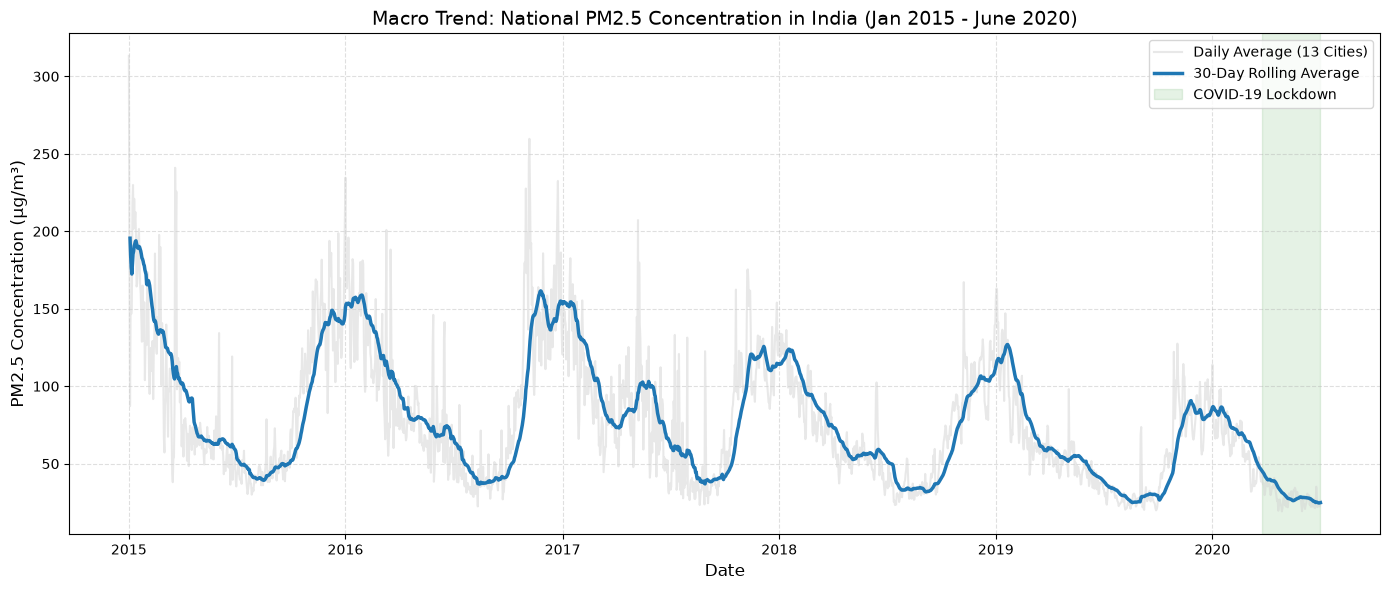

In [12]:
# Group by Date to average the 13 overlapping cities
daily_avg = (
    df.groupby("Date")["PM2.5"]
    .mean()
    .reset_index()
)
# Get the 30-day rolling mean
daily_avg["PM2.5_Rolling_30D"] = (
    daily_avg["PM2.5"]
    .rolling(
        window=30,
        # Use whatever observation is available if there is less than 30 days of data available, e.g. for the first month in the dataset
        # Using min_periods = 3 instead of 1 because the first two records are unusually high, which causes an unnatural spike at the start of the graph
        min_periods=3
    ).mean()
)

plt.figure(figsize=(14, 6))

# Plot the raw daily average in the background
sns.lineplot(
    data=daily_avg,
    x="Date",
    y="PM2.5",
    color="lightgrey",
    alpha=0.5,
    label="Daily Average (13 Cities)"
)

# Plot the smoothed trend line in the foreground
sns.lineplot(
    data=daily_avg,
    x="Date",
    y="PM2.5_Rolling_30D",
    linewidth=2.5,
    label="30-Day Rolling Average"
)

# Label the COVID-19 lockdown impact (Started March 25, 2020 in India)
plt.axvspan(
    pd.to_datetime("2020-03-25"),
    pd.to_datetime("2020-06-30"), 
    color="green",
    alpha=0.1,
    label="COVID-19 Lockdown"
)

plt.title("Macro Trend: National PM2.5 Concentration in India (Jan 2015 - June 2020)", fontsize=14)
plt.xlabel("Date", fontsize=12)
plt.ylabel("PM2.5 Concentration (µg/m³)", fontsize=12)
plt.legend(loc="upper right")
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

## Missing Value Bar Chart

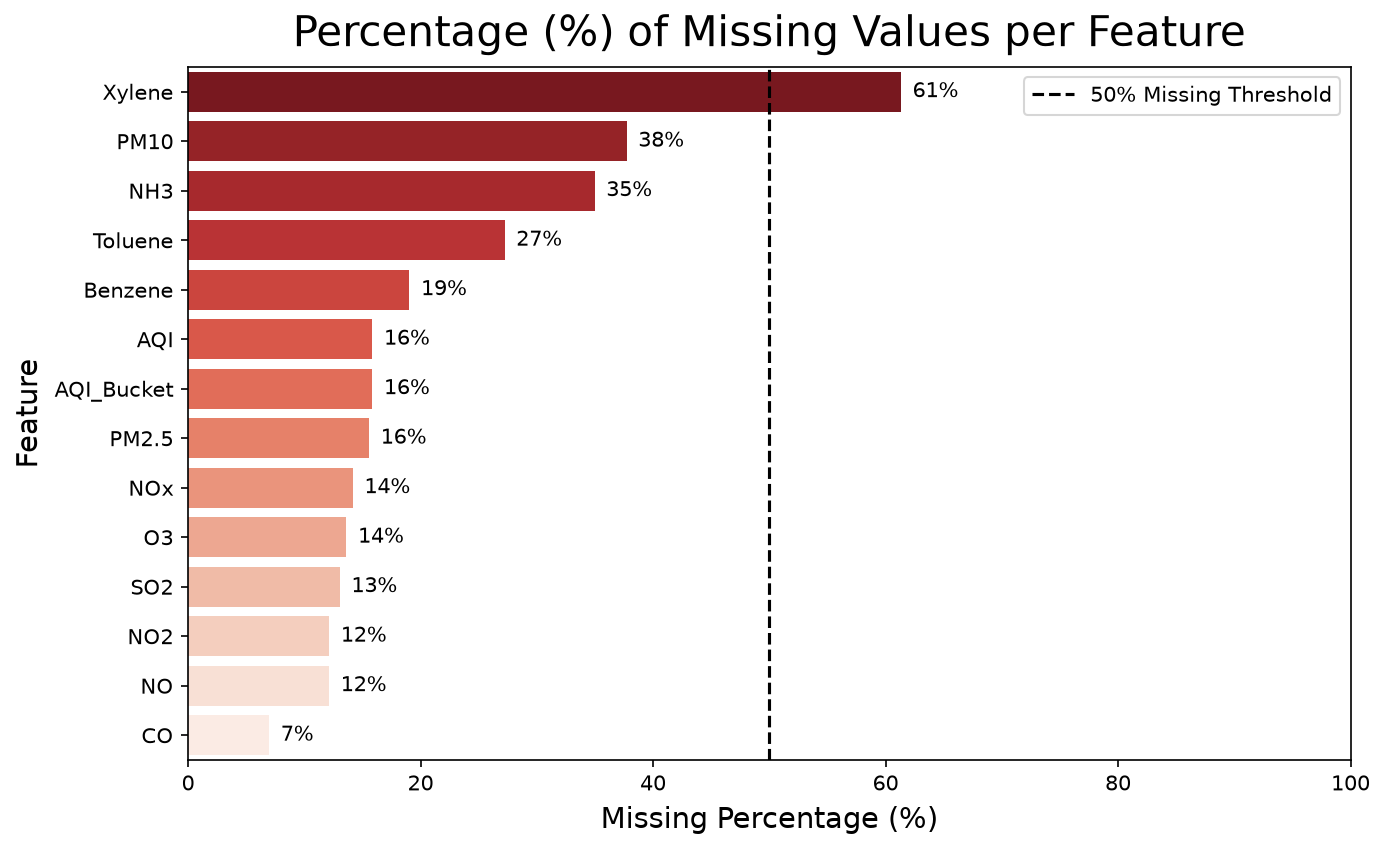

In [ ]:
# Calculate percentage of missing values for each column
missing_percentange = (df.isnull().sum() / len(df)) * 100

# Sort by descending
missing_df = missing_percentange[missing_percentange > 0].sort_values(
    ascending=False
).reset_index()

# Rename columns
missing_df.columns = ["Feature", "Missing Percentage"]

# Bar chart
plt.figure(
    figsize=(10, 6),
    dpi=150
)
sns.barplot(
    data=missing_df,
    x="Missing Percentage",
    y="Feature",
    palette="Reds_r",
    hue="Feature"
)

# Threshold line indicating columns with more than 50% missing values
plt.axvline(
    x=50,
    color="black",
    linestyle="--",
    label="50% Missing Threshold"
)

# Annotate with percentage
for index, value in enumerate(missing_df["Missing Percentage"]):
    plt.text(
        value + 1, # Controls the X position of the label
        index,
        f"{value:.0f}%",
        va="center", # Vertical alignment
    )

plt.title("Percentage (%) of Missing Values per Feature", fontsize=20, pad=10)
plt.xlabel("Missing Percentage (%)", fontsize=14, labelpad=5)
plt.xlim(right=100)
plt.ylabel("Feature", fontsize=14, labelpad=5)
plt.legend()
plt.show()

The columns Xylene, PM10, and NH3 have significant missing values.

## Correlation Heatmap of Pollutants

To visuailze the correlation between different pollutants to understand their relationships and potential sources of pollution.

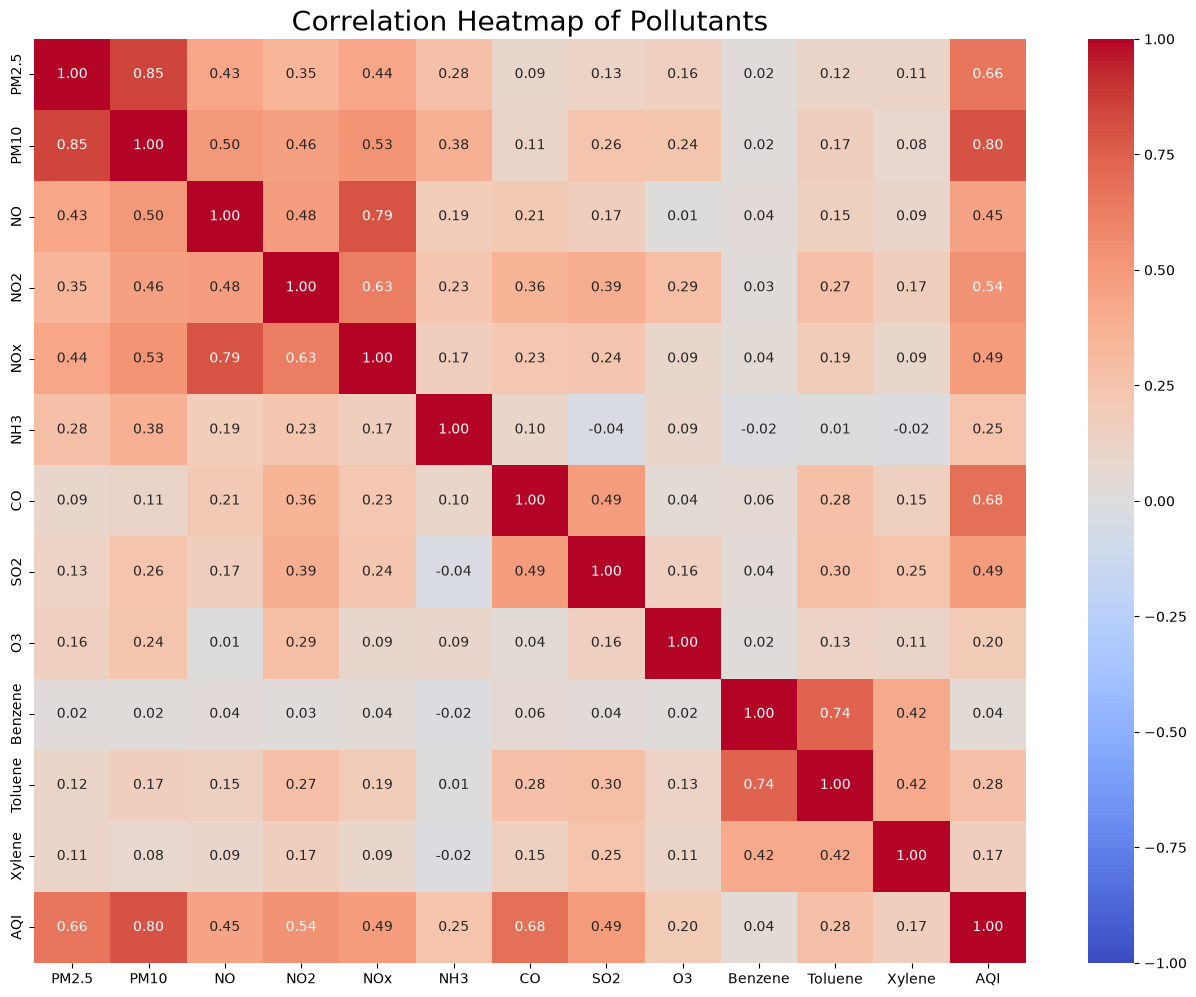

In [ ]:
plt.figure(figsize=(16, 12))
sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    fmt=".2f", # format
    vmax=1.0,
    vmin=-1.0,
    center=0.0,
)
plt.title("Correlation Heatmap of Pollutants", fontsize=20)
plt.show()

Based on the correlation heatmap, we can observe that Xylene has a low correlation (only 0.11) with our target variable, PM2.5. Therefore, we will drop the Xylene column from our dataset. Other columns with significant missing values such as PM10 and NH3 will be kept since they have a higher correlation with PM2.5 (0.63 and 0.55 respectively).

In [ ]:
# Drop Xylene column
# Results in 70% more rows (10654 rows) than keeping Xylene with only 6236 rows
df_dropped = df.drop(columns="Xylene")

# Drop any remaining rows with missing values
df_dropped = df_dropped.dropna().reset_index(drop=True)
df_dropped.shape

(10654, 15)

## Monthly Non-null Record Counts Group by Year

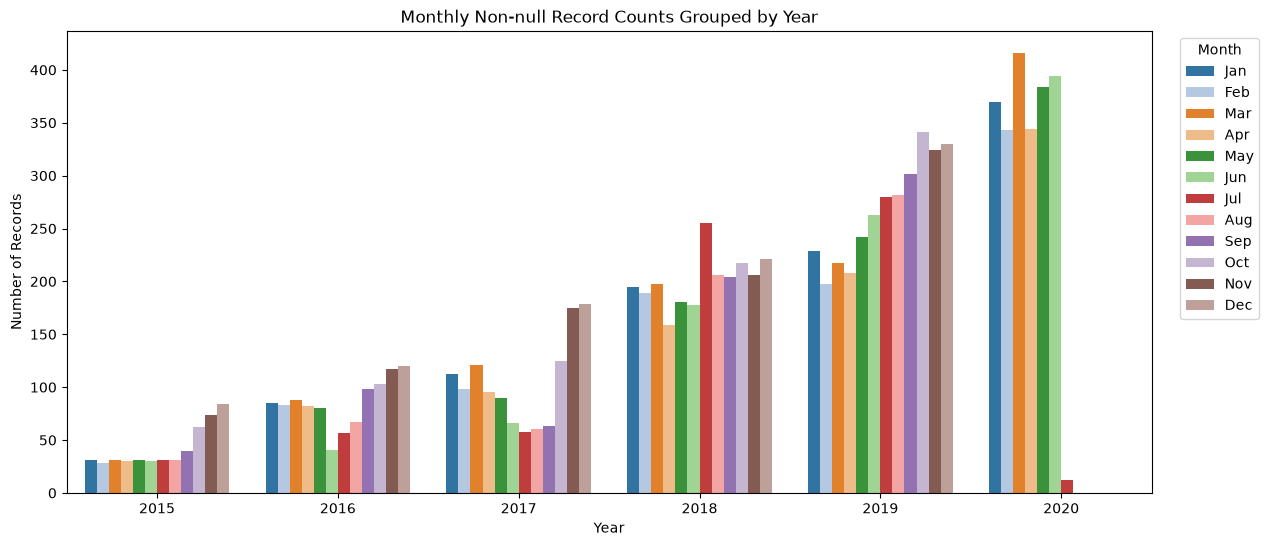

In [ ]:
# Exract Year and Month from the Date into its own columns
df_dropped["Year"] = df_dropped["Date"].dt.year
df_dropped["Month"] = df_dropped["Date"].dt.month

# Count records for each month of every year
monthly_counts = df_dropped.groupby(
    ["Year", "Month"]
).size().sort_index().reset_index(
    name="Count"
)

# Drop the Year column since it is no longer needed
df_dropped = df_dropped.drop(columns="Year")

# Map numeric month to 3-letter abbreviations
monthly_counts["Month_Name"] = monthly_counts["Month"].apply(
    lambda m: calendar.month_abbr[m]
)

plt.figure(figsize=(14, 6))
ax = sns.barplot(
    data=monthly_counts,
    x="Year",
    y="Count",
    hue="Month_Name",
    palette="tab20"
)

plt.title("Monthly Non-null Record Counts Grouped by Year")
plt.xlabel("Year")
plt.ylabel("Number of Records")
plt.legend(title="Month", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.show()

Most of the records are concentrated starting from October 2017 until June 2020. For a clean 3-year time span, we will use the data from July 2017 to June 2020 and drop the rest of the records.

In [ ]:
# Temporal Filtering: Extract rows between July 2017 and June 2020
df_temp = df_dropped[
    (df_dropped["Date"] >= "2017-07-01")
    & (df_dropped["Date"] <= "2020-06-30")
]

## Feature Engineering

In [ ]:
# Particulate Ratio (PM 2.5/PM 10)
df_temp["PM_Ratio"] = df_temp["PM2.5"]/df_temp["PM10"]

## Grouped Box Plot by Monsoon Season

In [ ]:
def assign_monsoon(month):
    """
    Categorizes month based on India"s seasons
    """
    
    if month in [1, 2]:
        # Dry Winter (Jan, Feb)
        return "Winter"
    elif month in [3, 4, 5]:
        # Pre-monsoon (March - May)
        return "Summer"
    elif month in [6, 7, 8, 9]:
        # SW/Summer Monsoon (June - Sept)
        return "SW_Monsoon"
    else:
        # NE/Winter Monsoon (Oct - Dec)
        return "NE_Monsoon"

df_temp["Season"] = df_temp["Month"].apply(assign_monsoon)

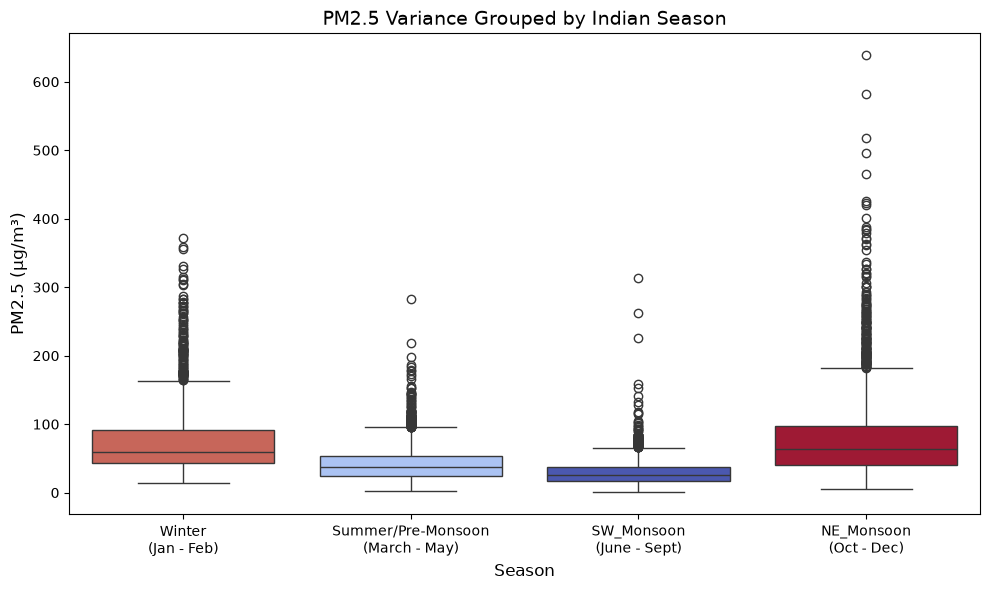

In [ ]:
plt.figure(figsize=(10, 6))

season_order = ["Winter", "Summer", "SW_Monsoon", "NE_Monsoon"]

# Calculate each season"s median PM2.5
season_medians = df_temp.groupby("Season")["PM2.5"].median()

# Normalize medians onto a 0 to 1 scale
norm = mcolors.Normalize(
    vmin=season_medians.min(),
    vmax=season_medians.max()
)

# Sample from the coolwarm color map
# Blue = lowest median / clean, Red = highest median / severe
cmap = cm.coolwarm
custom_palette = {
    season: cmap(norm(season_medians[season])) for season in season_order
}

sns.boxplot(
    data=df_temp, 
    x="Season", 
    y="PM2.5", 
    order=season_order,
    palette=custom_palette,
    hue="Season"
)

x_labels = [
    "Winter\n(Jan - Feb)",
    "Summer/Pre-Monsoon\n(March - May)",
    "SW_Monsoon\n(June - Sept)",
    "NE_Monsoon\n(Oct - Dec)"
]

plt.title("PM2.5 Variance Grouped by Indian Season", fontsize=14)
plt.xlabel("Season", fontsize=12)
plt.xticks(
    ticks=range(len(season_order)),
    labels=x_labels
)
plt.ylabel("PM2.5 (µg/m³)", fontsize=12)
plt.tight_layout()
plt.show()

From the grouped box plot, we can observe that the PM2.5 levels are highest during the Northeast Monsoon season (October to December) and lowest during the Southwest Monsoon season (June to September).

This indicates that air pollution levels in India are influenced by seasonal weather patterns, with higher pollution levels during the dry season and lower levels during the wet season.

## Geospatial Analysis of PM2.5 Levels in India

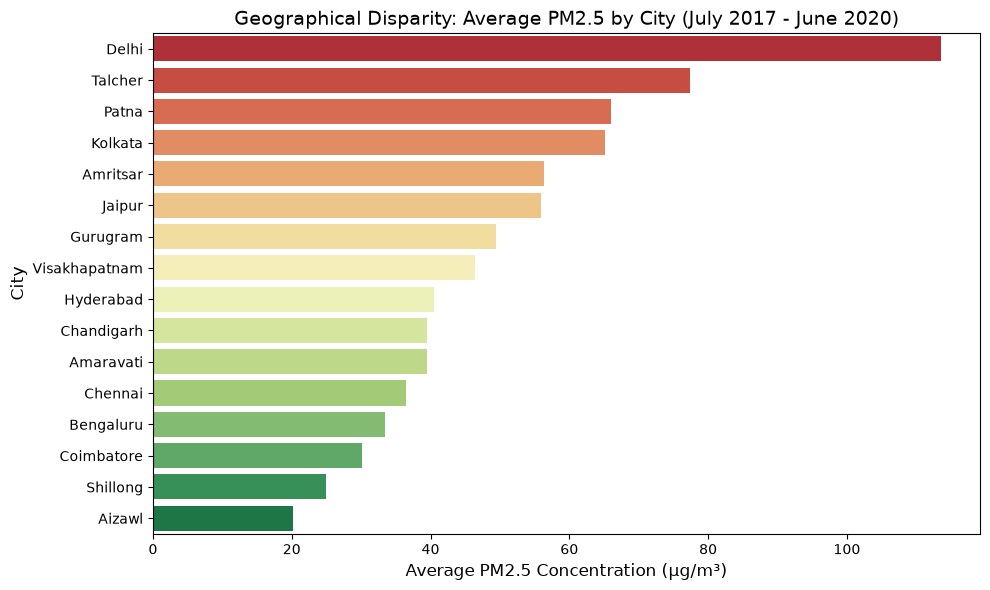

In [ ]:
plt.figure(figsize=(10, 6))

# Calculate means and sort for visual hierarchy
city_avg = (
    df_temp.groupby("City")["PM2.5"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

sns.barplot(
    data=city_avg, 
    x="PM2.5", 
    y="City", 
    palette="RdYlGn", # Green for Good, Red for Severe
    hue="City"
)
plt.title("Geographical Disparity: Average PM2.5 by City (July 2017 - June 2020)", fontsize=14)
plt.xlabel("Average PM2.5 Concentration (µg/m³)", fontsize=12)
plt.ylabel("City", fontsize=12)
plt.tight_layout()
plt.show()

From the bar chart, we can observe that the PM2.5 levels are highest in Delhi and lowest in Aizawl. This indicates that air pollution levels are influenced by geographical location, with urban areas having higher pollution levels compared to rural areas.

## One-Hot Encoding of Categorical Variables

Since the Season and City columns influence the PM2.5 levels, we will perform one-hot encoding on these categorical variables to convert them into numerical format for our machine learning model.

In [ ]:
df_encoded = pd.get_dummies(
    df_temp,
    columns=["Season", "City"],
    prefix=["Season", "City"],
    dtype=int,
    drop_first=False, # Retain all categories
)

df_encoded.columns

Index(['Date', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3',
       'Benzene', 'Toluene', 'AQI', 'AQI_Bucket', 'Month', 'PM_Ratio',
       'Season_NE_Monsoon', 'Season_SW_Monsoon', 'Season_Summer',
       'Season_Winter', 'City_Aizawl', 'City_Amaravati', 'City_Amritsar',
       'City_Bengaluru', 'City_Chandigarh', 'City_Chennai', 'City_Coimbatore',
       'City_Delhi', 'City_Gurugram', 'City_Hyderabad', 'City_Jaipur',
       'City_Kolkata', 'City_Patna', 'City_Shillong', 'City_Talcher',
       'City_Visakhapatnam'],
      dtype='str')

## AQI Category Bar Chart

In [ ]:
# Verify the AQI ranges for the AQI Categories
print(
    df_encoded.groupby("AQI_Bucket")["AQI"]
    .agg(["min", "max"])
    .sort_values(by="min")
)

                min    max
AQI_Bucket                
Good           14.0   50.0
Satisfactory   51.0  100.0
Moderate      101.0  200.0
Poor          201.0  300.0
Very Poor     301.0  400.0
Severe        401.0  677.0


C:\Users\Admin\AppData\Local\Temp\ipykernel_30228\2850956160.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


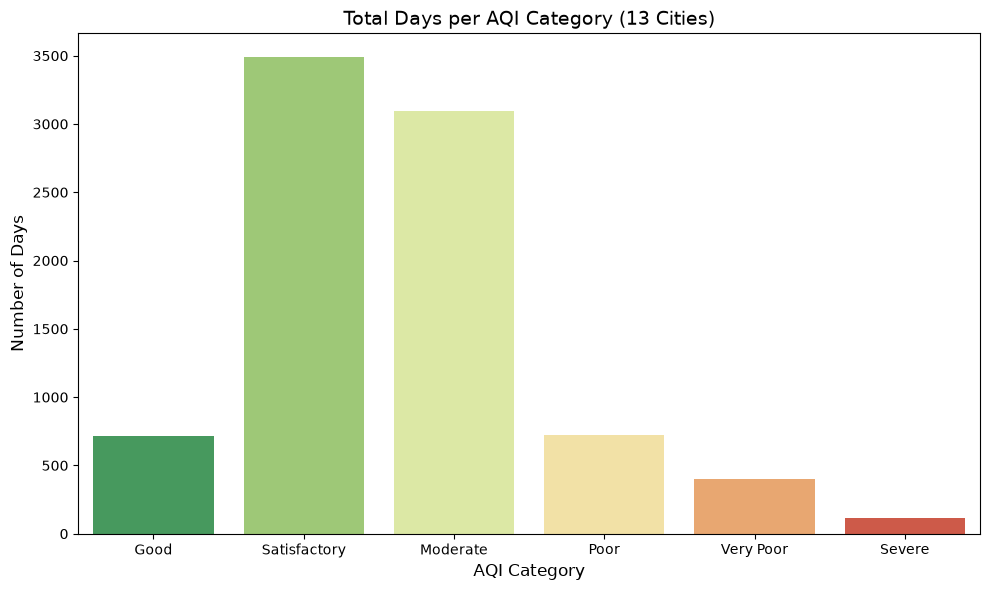

In [ ]:
plt.figure(figsize=(10, 6))

# Forcing the logical severity order
aqi_order = ["Good", "Satisfactory", "Moderate", "Poor", "Very Poor", "Severe"]

sns.countplot(
    data=df_encoded, 
    x="AQI_Bucket", 
    order=aqi_order, 
    palette="RdYlGn_r" # Green for Good, Red for Severe
)

plt.title("Total Days per AQI Category (13 Cities)", fontsize=14)
plt.xlabel("AQI Category", fontsize=12)
plt.ylabel("Number of Days", fontsize=12)
plt.tight_layout()
plt.show()

# Random Forest Regressor

Extract features and target variables. Certain columns have been dropped to avoid data leakage and multicollinearity issues. The target variable is the PM2.5 concentration, which is a key indicator of air pollution.

In [ ]:
features = df_encoded.drop(
    columns=["Date", "PM2.5", "PM10", "PM_Ratio", "AQI", "AQI_Bucket"]
)
target = df_encoded["PM2.5"]

In [ ]:
# Split dataset into 80% training and 20% test
x_train, x_test, y_train, y_test = train_test_split(
    features,
    target,
    test_size=0.2,
    random_state=10
)

In [ ]:
# Create base rf_model
base_rf = RandomForestRegressor(random_state=10)

## Hyperparameter Tuning using GridSearchCV

In [ ]:
param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [3, 5, 8, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", 1.0],
}

kf = KFold(
    n_splits=3,
    shuffle=True,
    random_state=10,
)

grid_search = GridSearchCV(
    estimator=base_rf,
    param_grid=param_grid,
    cv=kf,
    scoring="r2",
    n_jobs=-1
)
grid_search.fit(x_train, y_train)

best_rf = grid_search.best_estimator_

print("=== Best Hyperparameters ===")
print(grid_search.best_params_)

=== Best Hyperparameters ===
{'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}


## Evaluate Refined Model

In [ ]:
predictions = best_rf.predict(x_test)

print("\n=== Final Test Set Performance ===")
print(f"R-squared: {r2_score(y_test, predictions):.4f}")
print(f"MAE:       {mean_absolute_error(y_test, predictions):.4f} µg/m³")
print(f"RMSE:      {np.sqrt(mean_squared_error(y_test, predictions)):.4f} µg/m³")
mape = mean_absolute_percentage_error(y_test, predictions)
print(f"MAPE:      {mape * 100:.2f}%")


=== Final Test Set Performance ===
R-squared: 0.8520
MAE:       11.4183 µg/m³
RMSE:      20.8735 µg/m³
MAPE:      24.37%


## Feature Importance Chart

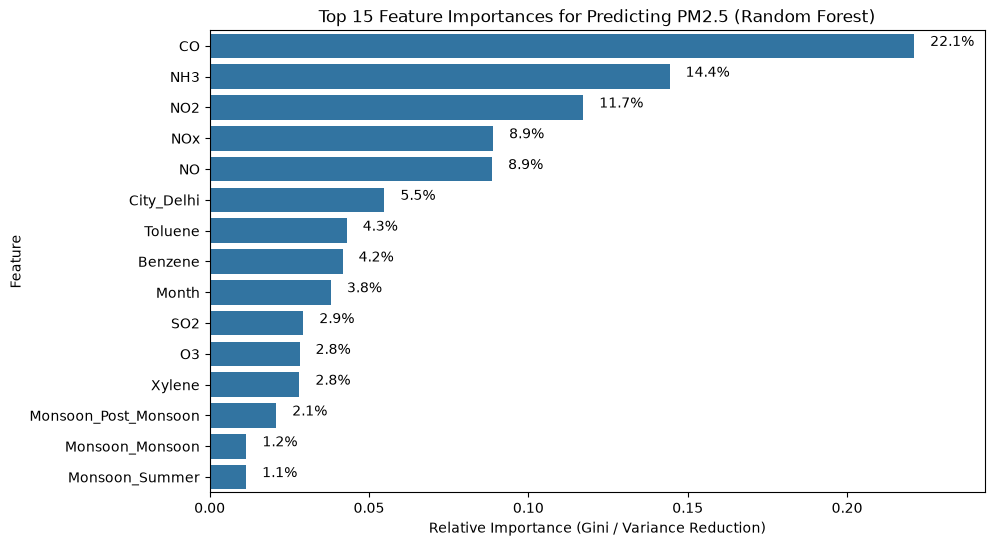

=== Top 15 Feature Importance Values ===
             Feature  Importance
                  CO    0.221057
                 NH3    0.144316
                 NO2    0.117230
                 NOx    0.088947
                  NO    0.088643
          City_Delhi    0.054854
             Toluene    0.043022
             Benzene    0.041722
               Month    0.038061
                 SO2    0.029402
                  O3    0.028224
              Xylene    0.028176
Monsoon_Post_Monsoon    0.020902
     Monsoon_Monsoon    0.011545
      Monsoon_Summer    0.011475


In [ ]:
importances = best_rf.feature_importances_

# Create a DataFrame and sort the features with descending importance
feature_importance_df = pd.DataFrame({
    "Feature": x_train.columns,
    "Importance": importances
}).sort_values(
    by="Importance",
    ascending=False
)

# Isolate top 15 features to prevent visual clutter
top_imp_df = feature_importance_df.head(15)

# Generate horizontal bar chart
plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_imp_df,
    x="Importance",
    y="Feature"
)

for index, val in enumerate(top_imp_df["Importance"]):
    plt.text(
        val + 0.005,
        index,
        f"{val * 100:.1f}%"
    )

plt.title("Top 15 Feature Importances for Predicting PM2.5 (Random Forest)")
plt.xlabel("Relative Importance (Gini / Variance Reduction)")
plt.ylabel("Feature")
plt.xlim(0, max(top_imp_df["Importance"]) * 1.1)
plt.show()

# Exact tabular values for report
print("=== Top 15 Feature Importance Values ===")
print(top_imp_df.to_string(index=False))